In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 윈도우 기준 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("폰트 설정 완료!")

폰트 설정 완료!


In [2]:
from pathlib import Path
import pandas as pd

# 현재 작업 폴더 기준 (노트북이 있는 폴더)
DATA_PATH = Path("online_retail_II.xlsx")

df_2009 = pd.read_excel(DATA_PATH, sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(DATA_PATH, sheet_name="Year 2010-2011")

print(df_2009.shape)
print(df_2009.head())

(525461, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


### 전체 흐름 : 2009·2010 거래 데이터를 합친 뒤, 취소·반품을 제거하지 않고 순매출(Net Sales)에 반영할 수 있도록 정리

In [3]:
# 1. 합치기
df = pd.concat([df_2009, df_2010], ignore_index=True)
print(f"2009-2010 시트: {len(df_2009):,}행")
print(f"2010-2011 시트: {len(df_2010):,}행")
print(f"합친 후 전체: {len(df):,}행")

# 2. 날짜 범위 확인
print(f"\n날짜 범위:")
print(f"시작: {df['InvoiceDate'].min()}")
print(f"종료: {df['InvoiceDate'].max()}")

2009-2010 시트: 525,461행
2010-2011 시트: 541,910행
합친 후 전체: 1,067,371행

날짜 범위:
시작: 2009-12-01 07:45:00
종료: 2011-12-09 12:50:00


### 1. 결측/사분위수 진단 출력 → 타입 정규화 → 중복 제거.
astype(str)을 실행하면  df.isnull().sum()이 Invoice/StockCode에 대해 무조건 0을 출력하는 것을 방지<br>
duplicated()를 돌리면 동일한 거래가 서로 다른 값 (예 : 536365와 '536365')으로 잡혀서 중복이 과소 탐지되는 것을 방지

In [4]:
# 1. 숫자형 칼럼 기초통계와 결측치
numeric_desc = df.describe()
numeric_desc.loc['missing'] = (
    df.select_dtypes(include='number')
    .isnull()
    .sum()
)

print("\n숫자형 칼럼 기초통계:")
print(numeric_desc)

# 2. 칼럼별 자료형
print("\n칼럼별 자료형:")
print(df.dtypes)

# 3. 전체 칼럼별 결측치
print("\n칼럼별 결측치:")
print(df.isnull().sum())




숫자형 칼럼 기초통계:
             Quantity                    InvoiceDate         Price  \
count    1.067371e+06                        1067371  1.067371e+06   
mean     9.938898e+00  2011-01-02 21:13:55.394028544  4.649388e+00   
min     -8.099500e+04            2009-12-01 07:45:00 -5.359436e+04   
25%      1.000000e+00            2010-07-09 09:46:00  1.250000e+00   
50%      3.000000e+00            2010-12-07 15:28:00  2.100000e+00   
75%      1.000000e+01            2011-07-22 10:23:00  4.150000e+00   
max      8.099500e+04            2011-12-09 12:50:00  3.897000e+04   
std      1.727058e+02                            NaN  1.235531e+02   
missing  0.000000e+00                            NaN  0.000000e+00   

           Customer ID  
count    824364.000000  
mean      15324.638504  
min       12346.000000  
25%       13975.000000  
50%       15255.000000  
75%       16797.000000  
max       18287.000000  
std        1697.464450  
missing  243007.000000  

칼럼별 자료형:
Invoice                ob

In [5]:
# ============================================================
# 변환 전 데이터 보관
# ============================================================
before_df = df.copy()

In [6]:
# ============================================================
# 전체 거래 기본 전처리
# ============================================================
# Invoice 열의 값을 문자열 형태로 변환
df['Invoice'] = (
    df['Invoice']

    # 숫자형·문자형이 섞여 있어도 모두 문자열로 통일
    # 취소 송장번호처럼 C536379 형태의 값도 안전하게 처리 가능
    .astype(str)

    # 문자열 앞뒤의 불필요한 공백 제거
    # 예: ' 536365 ' → '536365'
    .str.strip()
)


# StockCode 열의 값을 문자열 형태로 변환
df['StockCode'] = (
    df['StockCode']
    # 상품 코드에는 숫자뿐 아니라 85123A, POST 같은 문자도 있으므로
    # 문자열로 통일
    .astype(str)
    # 상품 코드 앞뒤의 불필요한 공백 제거
    # 예: ' 85123A ' → '85123A'
    .str.strip()
)


# InvoiceDate 열을 날짜·시간 자료형으로 변환
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    # 날짜로 변환할 수 없는 값은 오류를 발생시키지 않고 날짜형 결측값인 NaT로 변환
    errors='coerce'
)


# Quantity 열을 숫자형으로 변환
df['Quantity'] = pd.to_numeric(
    df['Quantity'],

    # 숫자로 변환할 수 없는 값은 오류 대신 NaN으로 변환
    errors='coerce'
)

# Price 열을 숫자형으로 변환
df['Price'] = pd.to_numeric(
    df['Price'],
    errors='coerce'
)


In [7]:
# InvoiceDate 변환 실패
failed_date = df[
    before_df['InvoiceDate'].notna()
    & df['InvoiceDate'].isna()
]

print("\nInvoiceDate 변환 실패 행:")
print(
    failed_date[
        ['Invoice', 'InvoiceDate']
    ].head(20)
)


# Quantity 변환 실패
failed_quantity = df[
    before_df['Quantity'].notna()
    & df['Quantity'].isna()
]

print("\nQuantity 변환 실패 행:")
print(
    failed_quantity[
        ['Invoice', 'StockCode', 'Quantity']
    ].head(20)
)


# Price 변환 실패
failed_price = df[
    before_df['Price'].notna()
    & df['Price'].isna()
]

print("\nPrice 변환 실패 행:")
print(
    failed_price[
        ['Invoice', 'StockCode', 'Price']
    ].head(20)
)


InvoiceDate 변환 실패 행:
Empty DataFrame
Columns: [Invoice, InvoiceDate]
Index: []

Quantity 변환 실패 행:
Empty DataFrame
Columns: [Invoice, StockCode, Quantity]
Index: []

Price 변환 실패 행:
Empty DataFrame
Columns: [Invoice, StockCode, Price]
Index: []


In [8]:
# 4. 완전 중복행 확인 및 제거
duplicate_count = df.duplicated().sum()#첫 번째 행을 제외한 추가 중복행 개수

print(f"\n중복행: {duplicate_count:,}개")

df = df.drop_duplicates().copy()

print(f"중복 제거 후 행 수: {len(df):,}개")
print(f"중복 제거 후 남은 중복행: {df.duplicated().sum():,}개")


중복행: 34,335개
중복 제거 후 행 수: 1,033,036개
중복 제거 후 남은 중복행: 0개


비회원 거래는 일별/ 월별 매출 칼럼으로 고려

In [9]:
# 비회원 거래 보존
df_all  = df.copy()  

In [10]:
# 분석에 반드시 필요한 주요 열에 결측값이 있는 행 제거
# df = df.dropna(
#     subset=[
#         # 거래 날짜가 없거나 날짜 변환에 실패한 행 제거
#         #'InvoiceDate',

#         # 고객을 식별할 수 없는 행 제거
#         'Customer ID',

#         # 수량이 없거나 숫자 변환에 실패한 행 제거
#         #'Quantity',

#         # 가격이 없거나 숫자 변환에 실패한 행 제거
#         #'Price'
#     ]
# )

# 고객 ID의 .0 표기를 제거하고 범주형 식별자로 사용하기 위해 문자열형으로 변환
# df['Customer ID'] = (
#     df['Customer ID']
#     .astype('int64')
#     .astype(str)
# )

In [11]:
# 결측값은 유지하고, 고객 ID의 소수점 표기(.0)를 제거한 뒤 문자열형으로 변환
df['Customer ID'] = (
    # 숫자로 변환하며, 변환 불가능한 값은 결측값으로 처리
    pd.to_numeric(df['Customer ID'], errors='coerce')

    # 결측값을 유지하면서 소수점 .0을 제거
    .astype('Int64')

    # 고객 식별자로 사용하기 위해 문자열형으로 변환
    .astype('string')
)

### 2. 문자로 시작하는 StockCode가 실제 상품인지, 배송비·수수료·조정값인지 탐색

In [12]:
# ============================================================
# 문자로 시작하는 StockCode 거래 확인
# 현재 전체 데이터 df 기준
# ============================================================

# StockCode가 영문자로 시작하는 거래 추출
text_codes = df[
    df['StockCode']
    .astype(str)
    .str.strip()
    .str.match(r'^[A-Za-z]', na=False)
].copy()


# Sales 칼럼이 아직 없다면 생성
if 'Sales' not in text_codes.columns:
    text_codes['Sales'] = (
        text_codes['Quantity']
        * text_codes['Price']
    )


# 송장번호 일부만 출력하는 함수
def invoice_preview(series, limit=3):
    invoices = (
        series
        .dropna()
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

    preview = ', '.join(invoices[:limit])

    if len(invoices) > limit:
        preview += f' ... 외 {len(invoices) - limit}개'

    return preview


# StockCode와 Description별 요약
text_summary = (
    text_codes
    .groupby(
        ['StockCode', 'Description'],
        dropna=False
    )
    .agg(
        거래행수=('Invoice', 'size'),
        송장수=('Invoice', 'nunique'),
        Invoice예시=('Invoice', invoice_preview),
        총수량=('Quantity', 'sum'),
        총매출=('Sales', 'sum')
    )
    .reset_index()
    .sort_values(
        ['거래행수', '총매출'],
        ascending=[False, False]
    )
)


# 결과 확인
print(f"문자로 시작하는 StockCode 거래행: {len(text_codes):,}개")
print(f"고유 StockCode 수: {text_codes['StockCode'].nunique():,}개")

print("\n문자로 시작하는 StockCode 요약:")
print(
    text_summary.to_string(
        index=False,
        formatters={
            '총수량': '{:,.0f}'.format,
            '총매출': '{:,.2f}'.format
        }
    )
)

문자로 시작하는 StockCode 거래행: 5,980개
고유 StockCode 수: 62개

문자로 시작하는 StockCode 요약:
   StockCode                         Description  거래행수  송장수                            Invoice예시    총수량         총매출
        POST                             POSTAGE  2079 2077   489439, 489444, 489447 ... 외 2074개  5,061  110,430.41
         DOT                      DOTCOM POSTAGE  1423 1423   489597, 489600, 489601 ... 외 1420개  1,417  309,844.10
           M                              Manual  1387 1286 489609, C489651, C489859 ... 외 1283개  4,193  -83,326.33
          C2                            CARRIAGE   274  274    490127, 490541, 490542 ... 외 271개    261   13,136.00
           D                            Discount   173  151 C489535, C491428, C491845 ... 외 148개 -2,868  -12,879.63
           S                             SAMPLES   101   37  C500305, C500309, C502083 ... 외 34개    -95   -5,991.11
BANK CHARGES                        Bank Charges    94   89  C500319, C500352, C500708 ... 외 86개    -40  -33,413.

In [15]:
# 명확한 비상품 코드 제거
non_product_codes = {
    'POST', 'DOT', 'M', 'C2', 'C3', 'D', 'S',
    'BANK CHARGES', 'AMAZONFEE', 'ADJUST', 'ADJUST2',
    'CRUK', 'B', 'PADS', 'TEST001', 'TEST002',
    'GIFT',   # Description NaN, 조정성 단건
}

# StockCode 대문자 통일 ('m'/'M', 'gift_0001_20' 등 표기 흔들림 흡수)
code_upper = df['StockCode'].str.upper()

# 각 행이 비상품인지 판단하는 Boolean 마스크
is_non_product = (
    code_upper.isin(non_product_codes)          # StockCode가 지정한 비상품 코드 목록에 포함되면 True.
    | code_upper.str.startswith('GIFT_0001')    # 코드가 GIFT_0001로 시작하면 True.
)

df = df[~is_non_product].copy()

### 3. 파생변수 생성
가격 0(샘플·증정품·오류)과 음수(조정) 거래를 제거하되, 수량 음수는 취소·반품을 순매출에 반영하기 위해 유지<br>
`Sales`(순매출) · `YearMonth`(월 집계 단위) · `is_purchase`(정상 구매) · `is_cancel`(취소) 생성

net-sales 방식 채택. 원주문과 취소를 직접 1대1로 매칭한 것은 아니기에 사용 가능 이유에 대한 설명 필요

In [16]:
# Price가 양수인 거래만 유지 - 가격 0인 샘플·증정품/가격 0인 잘못된 거래/음수 가격인 조정 거래 제거
# Quantity 음수는 취소·반품 순매출 반영을 위해 유지
df = df[
    df['Price'] > 0
].copy()

# 순매출
df['Sales'] = (
    df['Quantity']
    * df['Price']
)

# 월 단위 변수
df['YearMonth'] = (
    df['InvoiceDate']
    .dt.to_period('M')
)


# 실제 정상 구매 거래 여부
df['is_purchase'] = (
    ~df['Invoice'].str.startswith('C')
    & (df['Quantity'] > 0)
)

# 취소 거래 분석 참고용
df['is_cancel'] = (
    df['Invoice']
    .str.startswith('C', na=False)
)

print("전체 전처리 완료")
print("행 수:", len(df))
print(
    "기간:",
    df['InvoiceDate'].min(),
    "~",
    df['InvoiceDate'].max()
)

전체 전처리 완료
행 수: 1021254
기간: 2009-12-01 07:45:00 ~ 2011-12-09 12:50:00


In [ ]:
import os

os.makedirs('data', exist_ok=True)
OUT = 'data/retail_preprocessed'

df.to_parquet(f'{OUT}.parquet', index=False)                  # 작업용 (주 포맷)


In [ ]:
df.to_csv(f'{OUT}.csv', index=False, encoding='utf-8-sig')    # 확인·제출용

In [19]:
import os
print(os.path.abspath(f'{OUT}.parquet'))   # 실제 절대경로
print(os.path.exists(f'{OUT}.parquet'))    # True면 저장 성공

c:\Users\rladp\Desktop\online retail 2\data\retail_preprocessed.parquet
True


In [22]:
# ============================================================
# 회원 / 비회원 매출 비교
# ============================================================
na = df['Customer ID'].isna()

# --- 총액 요약 ---
tot = df['Sales'].sum()
cov = pd.DataFrame({
    '행수':   [(~na).sum(), na.sum(), len(df)],
    '순매출': [df.loc[~na, 'Sales'].sum(), df.loc[na, 'Sales'].sum(), tot]
}, index=['회원', '비회원', '전체'])
cov['행%']   = cov['행수']   / len(df) * 100
cov['매출%'] = cov['순매출'] / tot * 100

print(cov.round(2).to_string())
print(f"\n비회원 매출 총액: {df.loc[na, 'Sales'].sum():,.0f}")
print(f"회원   매출 총액: {df.loc[~na, 'Sales'].sum():,.0f}")
print(f"전체   매출 총액: {tot:,.0f}")

# --- 월별 집계 ---
m = df.groupby([df['YearMonth'], na])['Sales'].sum().unstack()
m.columns = ['회원', '비회원']
m.index = m.index.to_timestamp()
m['비회원비중%'] = m['비회원'] / (m['회원'] + m['비회원']) * 100

          행수          순매출      행%     매출%
회원    794165  16358629.29   77.76   86.43
비회원   227089   2568806.36   22.24   13.57
전체   1021254  18927435.65  100.00  100.00

비회원 매출 총액: 2,568,806
회원   매출 총액: 16,358,629
전체   매출 총액: 18,927,436


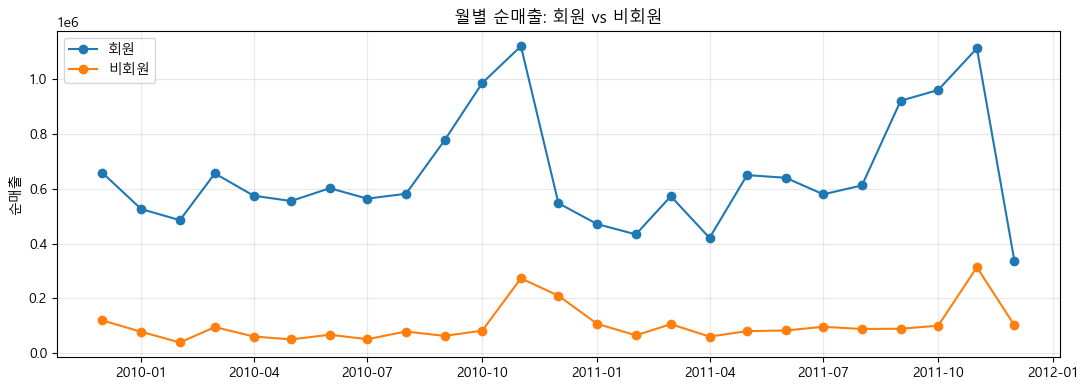

In [23]:
# --- 그래프 1: 월별 순매출 (회원 vs 비회원) ---
plt.figure(figsize=(11, 4))
plt.plot(m.index, m['회원'],   marker='o', label='회원')
plt.plot(m.index, m['비회원'], marker='o', label='비회원')
plt.title('월별 순매출: 회원 vs 비회원')
plt.ylabel('순매출')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

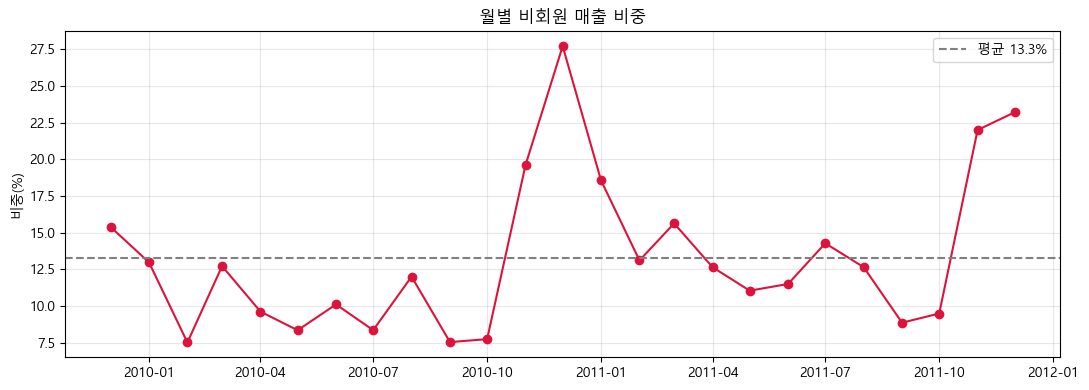

In [24]:
# --- 그래프 2: 월별 비회원 매출 비중 ---
plt.figure(figsize=(11, 4))
plt.plot(m.index, m['비회원비중%'], marker='o', color='crimson')
plt.axhline(m['비회원비중%'].mean(), ls='--', c='gray',
            label=f"평균 {m['비회원비중%'].mean():.1f}%")
plt.title('월별 비회원 매출 비중')
plt.ylabel('비중(%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()